In [1]:
import json
import torch
import torch.nn as nn
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# PyTorch
import torch

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# Upload train, test, valid splits pre-saved from first experience

SPLITS_DIR = Path("/kaggle/input/datasets/ebyeager/splits")

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
valid_df = pd.read_csv(SPLITS_DIR / "valid_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))

Train: 907
Valid: 194
Test : 195


In [3]:
!pip install -q segmentation-models-pytorch albumentations
!pip install -q transformers

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.1 MB/s eta 0:00:00


In [4]:
# Augmentation

import albumentations as A

IMAGE_HEIGHT = 384
IMAGE_WIDTH = 512

train_transform = A.Compose([
    A.Resize(
        IMAGE_HEIGHT,
        IMAGE_WIDTH
    ),

    A.HorizontalFlip(p=0.5),

    A.Affine(
        scale=(0.90, 1.10),
        translate_percent=(-0.05, 0.05),
        rotate=(-10, 10),
        shear=(-3, 3),
        border_mode=0,
        p=0.5
    ),

    A.OneOf([
        A.GaussNoise(p=1.0),
        A.GaussianBlur(
            blur_limit=(3, 5),
            p=1.0
        ),
    ], p=0.15),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

valid_transform = A.Compose([
    A.Resize(
        IMAGE_HEIGHT,
        IMAGE_WIDTH
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])


# PyTorch Dataset

from torch.utils.data import Dataset, DataLoader


class HumidityDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.loc[idx, "image"]
        mask_path = self.df.loc[idx, "mask"]

        # Read image
        image = np.array(Image.open(image_path).convert("RGB"))

        # Read mask
        mask = np.array(Image.open(mask_path).convert("L"))

        # Convert to binary
        mask = (mask > 0).astype(np.float32)

        # Albumentations
        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        # HWC -> CHW
        image = torch.from_numpy(
            image.transpose(2, 0, 1)
        ).float()

        mask = torch.from_numpy(mask).float()

        # Add channel dimension
        mask = mask.unsqueeze(0)

        return image, mask


# DataLoaders

BATCH_SIZE = 8
NUM_WORKERS = 2

train_dataset = HumidityDataset(
    train_df,
    transform=train_transform
)

valid_dataset = HumidityDataset(
    valid_df,
    transform=valid_transform
)

test_dataset = HumidityDataset(
    test_df,
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

def denormalize(image):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image.transpose(1, 2, 0)
    image = image * std + mean

    return np.clip(image, 0, 1)


# Metrics

def segmentation_metrics(
    logits,
    masks,
    threshold=0.5,
    eps=1e-7
):
    """
    Compute batch-level binary segmentation metrics.
    """

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    masks = masks.float()

    predictions = predictions.view(predictions.size(0), -1)
    masks = masks.view(masks.size(0), -1)

    tp = (predictions * masks).sum(dim=1)
    fp = (predictions * (1 - masks)).sum(dim=1)
    fn = ((1 - predictions) * masks).sum(dim=1)

    dice = (
        (2 * tp + eps) /
        (2 * tp + fp + fn + eps)
    )

    iou = (
        (tp + eps) /
        (tp + fp + fn + eps)
    )

    precision = (
        (tp + eps) /
        (tp + fp + eps)
    )

    recall = (
        (tp + eps) /
        (tp + fn + eps)
    )

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item()
    }
    
# Loss functions

import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probabilities = torch.sigmoid(logits)

        probabilities = probabilities.view(
            probabilities.size(0), -1
        )

        targets = targets.view(
            targets.size(0), -1
        )

        intersection = (
            probabilities * targets
        ).sum(dim=1)

        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                probabilities.sum(dim=1)
                +
                targets.sum(dim=1)
                +
                self.smooth
            )
        )

        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):

    def __init__(
        self,
        bce_weight=0.5,
        dice_weight=0.5
    ):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):

        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)

        total_loss = (
            self.bce_weight * bce_loss
            +
            self.dice_weight * dice_loss
        )

        return total_loss

In [5]:
criterion_deeplab = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

def segformer_loss(logits, masks):

    # Resize logits to ground-truth resolution
    logits = F.interpolate(
        logits,
        size=masks.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    # Masks: [B, 1, H, W] -> [B, H, W]
    targets = masks.squeeze(1).long()

    # Cross Entropy
    ce_loss = F.cross_entropy(
        logits,
        targets
    )

    # Probability of humidity class
    probs = torch.softmax(
        logits,
        dim=1
    )[:, 1]

    targets_float = targets.float()

    smooth = 1e-6

    intersection = (
        probs * targets_float
    ).sum(dim=(1, 2))

    denominator = (
        probs.sum(dim=(1, 2))
        + targets_float.sum(dim=(1, 2))
    )

    dice = (
        (2 * intersection + smooth)
        / (denominator + smooth)
    ).mean()

    dice_loss = 1 - dice

    return (
        0.5 * ce_loss
        + 0.5 * dice_loss
    )


criterion = segformer_loss

In [6]:
# DeepLab Loader

def load_deeplab_model(model, checkpoint_path, device):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.to(device)
    model.eval()

    print("Loaded:", checkpoint_path)
    print("Best epoch:", checkpoint["epoch"])
    print(
        "Best validation Dice:",
        checkpoint["best_val_dice"]
    )

    return model

# Segformer Loader

def load_segformer_model(model, checkpoint_path, device):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.to(device)
    model.eval()

    print("Loaded:", checkpoint_path)
    print("Best epoch:", checkpoint["epoch"])
    print(
        "Best validation Dice:",
        checkpoint["best_val_dice"]
    )

    return model

In [7]:
# Load models

DEEPLAB_R34_CHECKPOINT = Path(
    "/kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet34_best.pth"
)

DEEPLAB_R50_CHECKPOINT = Path(
    "/kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth"
)

DEEPLAB_EFFB2_CHECKPOINT=Path("/kaggle/input/datasets/ebyeager/results/deeplabv3plus_efficientnet_b2_best.pth"
)

SEGFORMER_B0_CHECKPOINT = Path("/kaggle/input/datasets/ebyeager/results/segformer_mit_b0_best.pth"
)

SEGFORMER_B1_CHECKPOINT = Path(
    "/kaggle/input/datasets/ebyeager/results/segformer_mit_b1_best.pth"
)

In [8]:
# ReCreating architectures

deeplab_r34 = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

deeplab_r50 = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

deeplab_effb2=smp.DeepLabV3Plus(
    encoder_name="timm-efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

segformer_b0 = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2,
    ignore_mismatched_sizes=True
)

segformer_b1 = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b1",
    num_labels=2,
    ignore_mismatched_sizes=True
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/54.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b1
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

model.safetensors:   0%|          | 0.00/54.7M [00:00<?, ?B/s]

In [10]:
# Loading the models

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

deeplab_r34 = load_deeplab_model(
    deeplab_r34,
    DEEPLAB_R34_CHECKPOINT,
    DEVICE
)

deeplab_r50 = load_deeplab_model(
    deeplab_r50,
    DEEPLAB_R50_CHECKPOINT,
    DEVICE
)

deeplab_effb2 = load_deeplab_model(
    deeplab_effb2,
    DEEPLAB_EFFB2_CHECKPOINT,
    DEVICE
)

segformer_b0 = load_segformer_model(
    segformer_b0,
    SEGFORMER_B0_CHECKPOINT,
    DEVICE
)

segformer_b1 = load_segformer_model(
    segformer_b1,
    SEGFORMER_B1_CHECKPOINT,
    DEVICE
)

print(DEVICE)

Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet34_best.pth
Best epoch: 36
Best validation Dice: 0.838582387904531
Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth
Best epoch: 27
Best validation Dice: 0.8363088381659124
Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_efficientnet_b2_best.pth
Best epoch: 33
Best validation Dice: 0.8289971228727361
Loaded: /kaggle/input/datasets/ebyeager/results/segformer_mit_b0_best.pth
Best epoch: 14
Best validation Dice: 0.8373637056350708
Loaded: /kaggle/input/datasets/ebyeager/results/segformer_mit_b1_best.pth
Best epoch: 26
Best validation Dice: 0.8484352397918701
cuda


In [11]:
# Validation epoch functions

@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    running_loss = 0.0
    n_samples = 0
    metric_totals = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }
    for images, masks in loader:
        images = images.to(
            device,
            non_blocking=True
        )
        masks = masks.to(
            device,
            non_blocking=True
        )
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            logits = model(images)

            loss = criterion(
                logits,
                masks
            )
        batch_size = images.size(0)
        running_loss += (
            loss.item() * batch_size
        )
        metrics = segmentation_metrics(
            logits,
            masks
        )
        for key in metric_totals:
            metric_totals[key] += (
                metrics[key] * batch_size
            )
        n_samples += batch_size
    results = {
        "loss": running_loss / n_samples
    }
    for key in metric_totals:
        results[key] = (
            metric_totals[key] / n_samples
        )
    return results


@torch.no_grad()
def validate_one_epoch_segformer(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0
    num_batches = 0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)
        targets = masks.squeeze(1).long()
        outputs = model(images)
        logits = outputs.logits
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        loss = criterion(
            logits,
            masks
        )
        predictions = torch.argmax(
            logits,
            dim=1
        )
        pred = predictions.float()
        target = targets.float()
        pred_flat = pred.view(pred.shape[0], -1)
        target_flat = target.view(target.shape[0], -1)
        tp = (
            pred_flat * target_flat
        ).sum(dim=1)
        fp = (
            pred_flat * (1 - target_flat)
        ).sum(dim=1)
        fn = (
            (1 - pred_flat) * target_flat
        ).sum(dim=1)
        eps = 1e-7
        dice = (
            (2 * tp + eps) /
            (2 * tp + fp + fn + eps)
        )
        iou = (
            (tp + eps) /
            (tp + fp + fn + eps)
        )
        precision = (
            (tp + eps) /
            (tp + fp + eps)
        )
        recall = (
            (tp + eps) /
            (tp + fn + eps)
        )
        total_loss += loss.item()
        total_dice += dice.mean().item()
        total_iou += iou.mean().item()
        total_precision += precision.mean().item()
        total_recall += recall.mean().item()
        num_batches += 1
    return {
        "loss": total_loss / num_batches,
        "dice": total_dice / num_batches,
        "iou": total_iou / num_batches,
        "precision": total_precision / num_batches,
        "recall": total_recall / num_batches
    }

In [13]:
# Evaluate all three on the SAME test set

test_results_r34 = validate_one_epoch(
    deeplab_r34,
    test_loader,
    criterion_deeplab,
    DEVICE
)

test_results_r50 = validate_one_epoch(
    deeplab_r50,
    test_loader,
    criterion_deeplab,
    DEVICE
)

test_results_effb2 = validate_one_epoch(
    deeplab_effb2,
    test_loader,
    criterion_deeplab,
    DEVICE
)

test_results_b0 = validate_one_epoch_segformer(
    segformer_b0,
    test_loader,
    segformer_loss,
    DEVICE
)

test_results_b1 = validate_one_epoch_segformer(
    segformer_b1,
    test_loader,
    segformer_loss,
    DEVICE
)

In [14]:
print("=" * 70)
print("FINAL TOP-5 MODEL COMPARISON")
print("=" * 70)

results = {
    "DeepLabV3+ ResNet34": test_results_r34,
    "DeepLabV3+ ResNet50": test_results_r50,
    "DeepLabV3+ Effb2": test_results_effb2,
    "SegFormer-B0": test_results_b0,
    "SegFormer-B1": test_results_b1
}

for model_name, metrics in results.items():

    print(f"\n{model_name}")
    print("-" * 40)

    for metric, value in metrics.items():

        print(
            f"{metric.capitalize():12s}: "
            f"{value:.4f}"
        )

FINAL TOP-5 MODEL COMPARISON

DeepLabV3+ ResNet34
----------------------------------------
Loss        : 0.1822
Dice        : 0.8305
Iou         : 0.7493
Precision   : 0.8691
Recall      : 0.8459

DeepLabV3+ ResNet50
----------------------------------------
Loss        : 0.1630
Dice        : 0.8354
Iou         : 0.7538
Precision   : 0.8515
Recall      : 0.8688

DeepLabV3+ Effb2
----------------------------------------
Loss        : 0.1895
Dice        : 0.8225
Iou         : 0.7381
Precision   : 0.8551
Recall      : 0.8513

SegFormer-B0
----------------------------------------
Loss        : 0.2198
Dice        : 0.8309
Iou         : 0.7494
Precision   : 0.8354
Recall      : 0.8790

SegFormer-B1
----------------------------------------
Loss        : 0.2286
Dice        : 0.8293
Iou         : 0.7479
Precision   : 0.8591
Recall      : 0.8538


### qualitative comparison

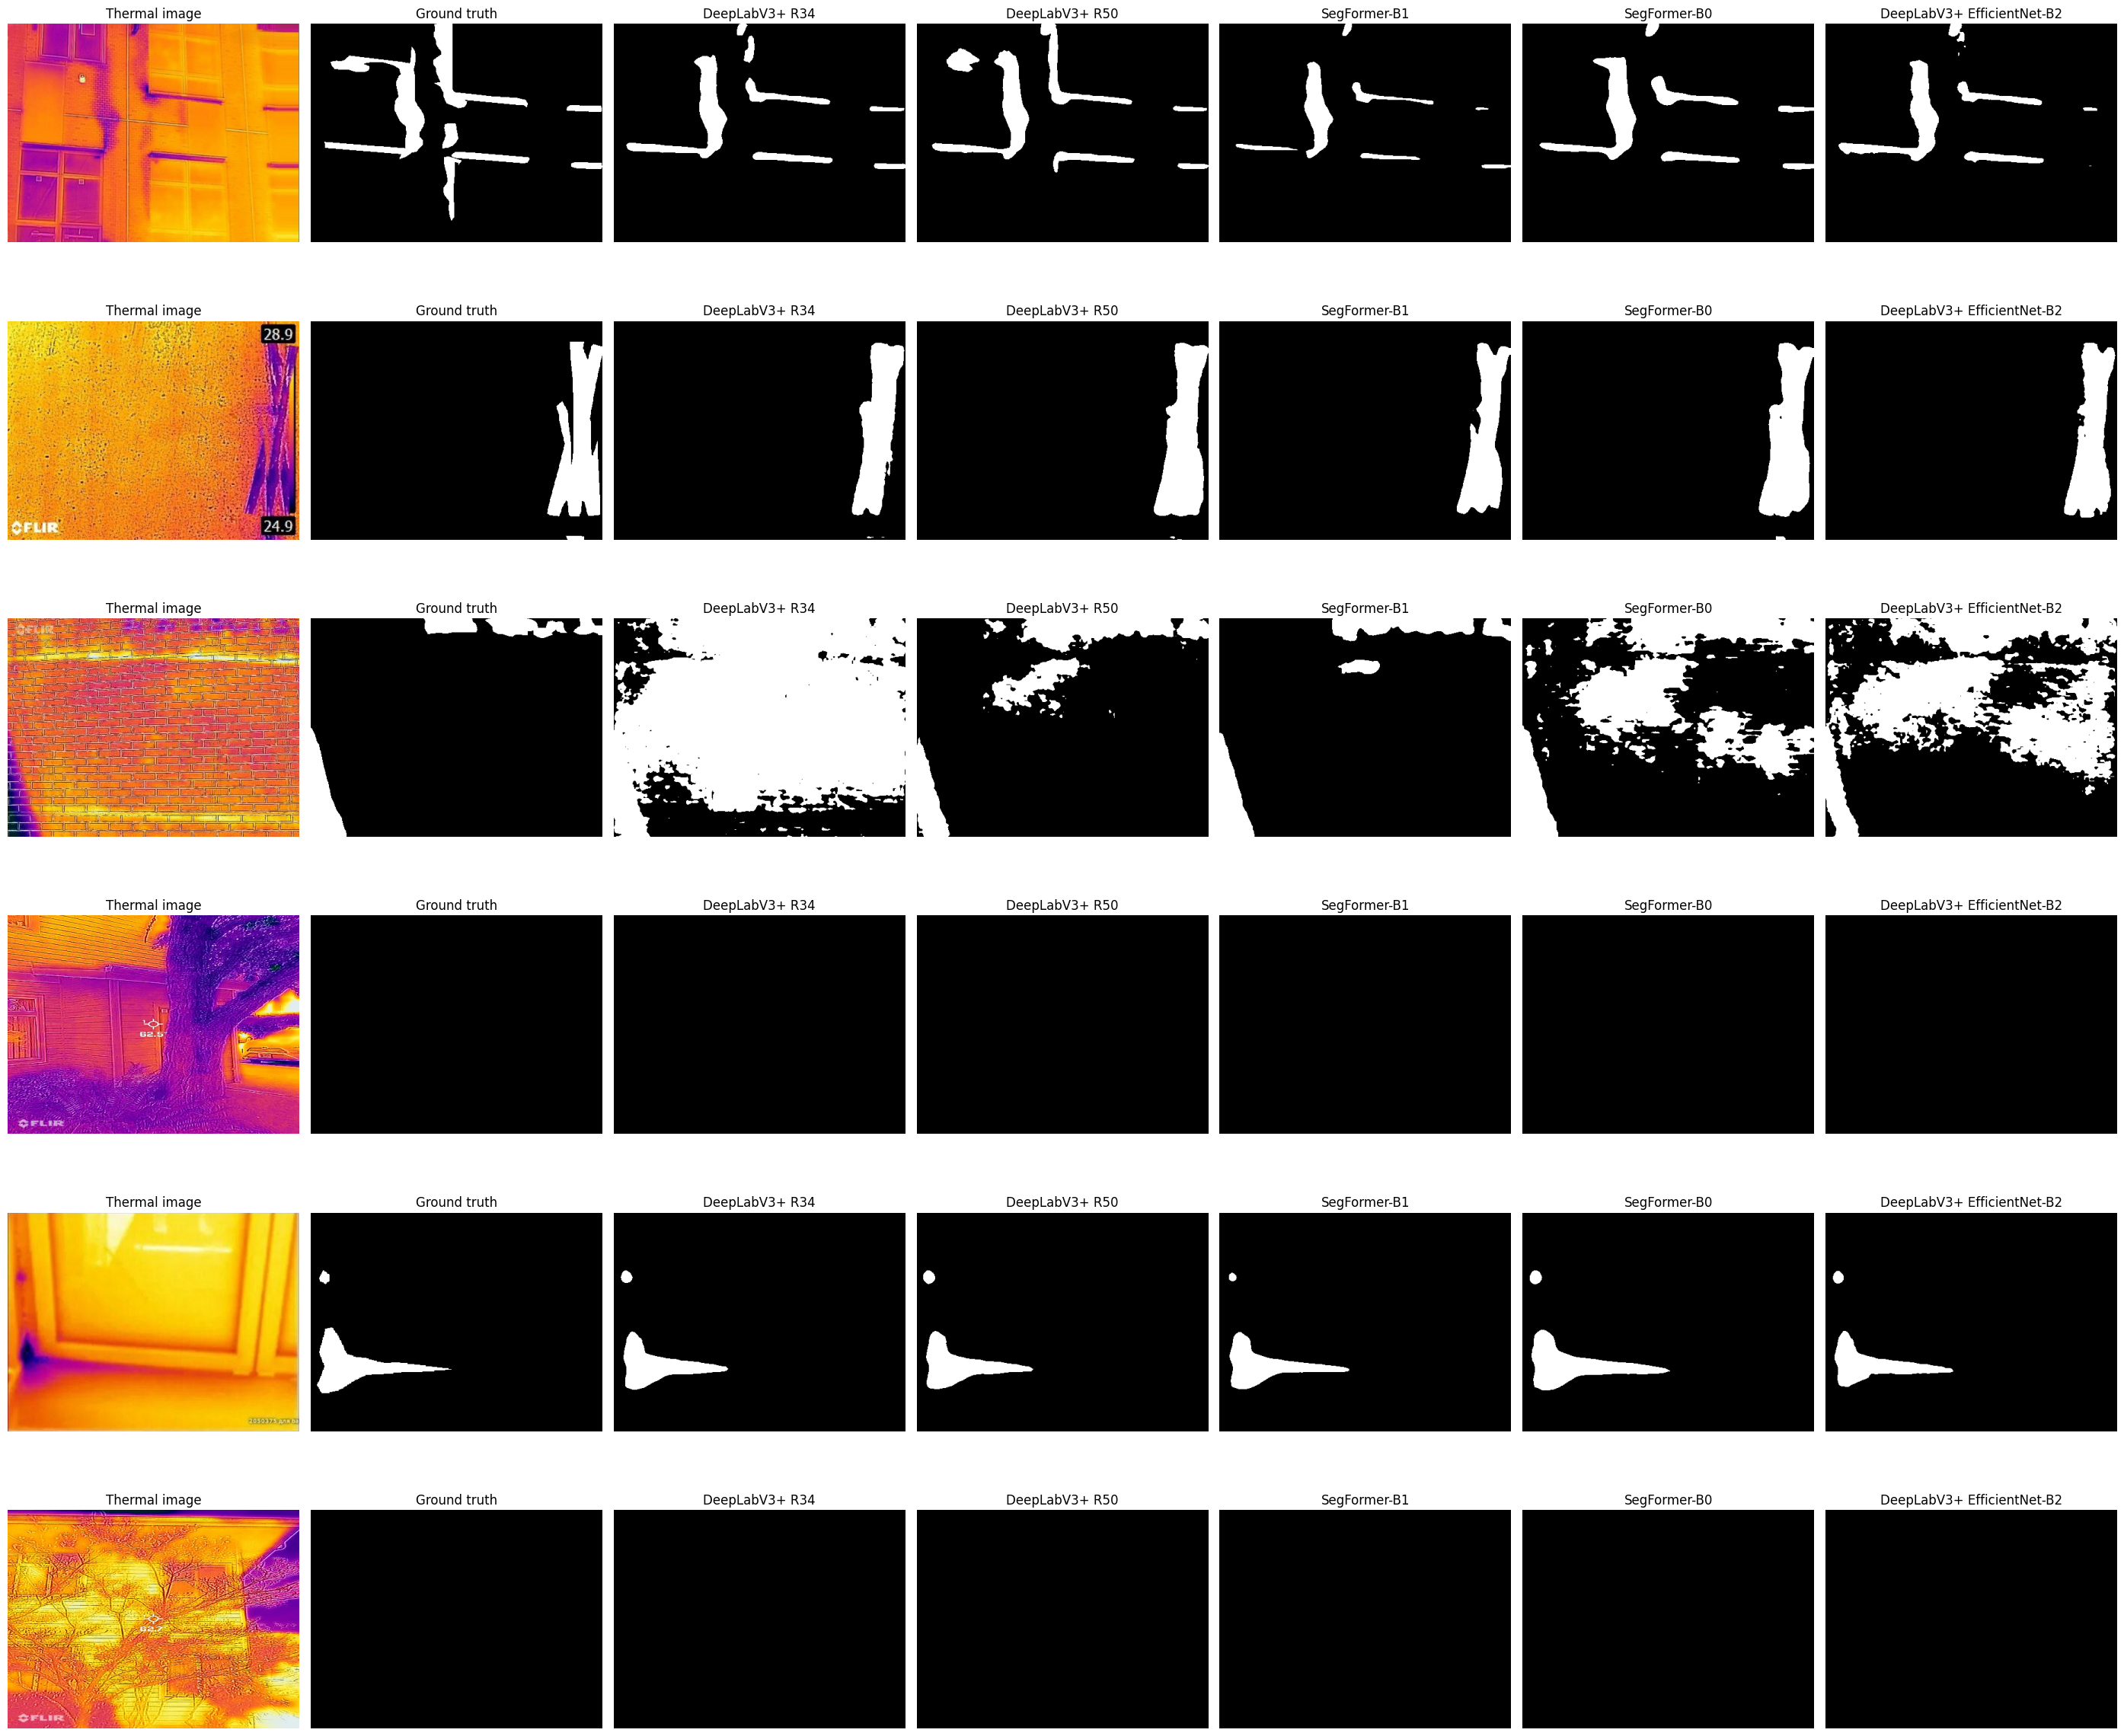

In [16]:
@torch.no_grad()
def compare_predictions(
    models,
    dataset,
    device,
    n=6
):

    for model in models.values():
        model.eval()

    indices = np.random.default_rng(SEED).choice(
        len(dataset),
        size=n,
        replace=False
    )

    fig, axes = plt.subplots(
        n,
        7,
        figsize=(28, 4 * n)
    )

    if n == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):

        image, mask = dataset[idx]

        input_tensor = (
            image.unsqueeze(0)
            .to(device)
        )

        image_np = denormalize(
            image.numpy()
        )

        mask_np = mask[0].numpy()

        # -------------------------
        # DeepLab ResNet34
        # -------------------------

        logits_r34 = models["DeepLabV3+ ResNet34"](
            input_tensor
        )

        pred_r34 = torch.sigmoid(
            logits_r34
        )[0, 0].cpu().numpy()

        pred_r34_binary = pred_r34 >= 0.5

        # -------------------------
        # DeepLab ResNet50
        # -------------------------

        logits_r50 = models["DeepLabV3+ ResNet50"](
            input_tensor
        )

        pred_r50 = torch.sigmoid(
            logits_r50
        )[0, 0].cpu().numpy()

        pred_r50_binary = pred_r50 >= 0.5

        # -------------------------
        # SegFormer B1
        # -------------------------

        outputs_b1 = models["SegFormer-B1"](
            pixel_values=input_tensor
        )

        logits_b1 = F.interpolate(
            outputs_b1.logits,
            size=mask_np.shape,
            mode="bilinear",
            align_corners=False
        )

        pred_b1 = torch.softmax(
            logits_b1,
            dim=1
        )[0, 1].cpu().numpy()

        pred_b1_binary = pred_b1 >= 0.5

        # -------------------------
        # SegFormer B0
        # -------------------------
        
        outputs_b0 = models["SegFormer-B0"](
            pixel_values=input_tensor
        )
        
        logits_b0 = F.interpolate(
            outputs_b0.logits,
            size=mask_np.shape,
            mode="bilinear",
            align_corners=False
        )
        
        pred_b0 = torch.softmax(
            logits_b0,
            dim=1
        )[0, 1].cpu().numpy()
        
        pred_b0_binary = pred_b0 >= 0.5
        
        
        # -------------------------
        # DeepLab EfficientNet-B2
        # -------------------------
        
        logits_effb2 = models["DeepLabV3+ EfficientNet-B2"](
            input_tensor
        )
        
        pred_effb2 = torch.sigmoid(
            logits_effb2
        )[0, 0].cpu().numpy()
        
        pred_effb2_binary = pred_effb2 >= 0.5

        # -------------------------
        # Plot
        # -------------------------

        axes[row, 0].imshow(image_np)
        axes[row, 0].set_title(
            "Thermal image"
        )

        axes[row, 1].imshow(
            mask_np,
            cmap="gray"
        )
        axes[row, 1].set_title(
            "Ground truth"
        )

        axes[row, 2].imshow(
            pred_r34_binary,
            cmap="gray"
        )
        axes[row, 2].set_title(
            "DeepLabV3+ R34"
        )

        axes[row, 3].imshow(
            pred_r50_binary,
            cmap="gray"
        )
        axes[row, 3].set_title(
            "DeepLabV3+ R50"
        )

        axes[row, 4].imshow(
            pred_b1_binary,
            cmap="gray"
        )
        axes[row, 4].set_title(
            "SegFormer-B1"
        )

        axes[row, 5].imshow(
            pred_b0_binary,
            cmap="gray"
        )
        axes[row, 5].set_title("SegFormer-B0")
        
        axes[row, 6].imshow(
            pred_effb2_binary,
            cmap="gray"
        )
        axes[row, 6].set_title("DeepLabV3+ EfficientNet-B2")

        for col in range(7):
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


models = {
    "DeepLabV3+ ResNet34": deeplab_r34,
    "DeepLabV3+ ResNet50": deeplab_r50,
    "DeepLabV3+ EfficientNet-B2": deeplab_effb2,
    "SegFormer-B0": segformer_b0,
    "SegFormer-B1": segformer_b1
}

compare_predictions(
    models,
    test_dataset,
    DEVICE,
    n=6
)

In [17]:
# Error Analysis

@torch.no_grad()
def calculate_error_statistics(
    model,
    dataset,
    device,
    model_type="deeplab"
):

    model.eval()

    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_tn = 0

    image_errors = []

    for idx in range(len(dataset)):

        image, mask = dataset[idx]

        input_tensor = (
            image.unsqueeze(0)
            .to(device)
        )

        mask_np = mask[0].numpy().astype(bool)

        if model_type == "deeplab":

            logits = model(input_tensor)

            prediction = torch.sigmoid(
                logits
            )[0, 0].cpu().numpy()

        else:

            outputs = model(
                pixel_values=input_tensor
            )

            logits = F.interpolate(
                outputs.logits,
                size=mask_np.shape,
                mode="bilinear",
                align_corners=False
            )

            prediction = torch.softmax(
                logits,
                dim=1
            )[0, 1].cpu().numpy()

        pred_np = prediction >= 0.5

        tp = np.logical_and(
            pred_np,
            mask_np
        ).sum()

        fp = np.logical_and(
            pred_np,
            ~mask_np
        ).sum()

        fn = np.logical_and(
            ~pred_np,
            mask_np
        ).sum()

        tn = np.logical_and(
            ~pred_np,
            ~mask_np
        ).sum()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

        image_errors.append({
            "index": idx,
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "error": int(fp + fn)
        })

    return {
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "TN": total_tn,
        "image_errors": image_errors
    }

In [18]:
errors_r34 = calculate_error_statistics(
    deeplab_r34,
    test_dataset,
    DEVICE,
    "deeplab"
)

errors_r50 = calculate_error_statistics(
    deeplab_r50,
    test_dataset,
    DEVICE,
    "deeplab"
)

errors_effb2 = calculate_error_statistics(
    deeplab_effb2,
    test_dataset,
    DEVICE,
    "deeplab"
)

errors_b0 = calculate_error_statistics(
    segformer_b0,
    test_dataset,
    DEVICE,
    "segformer"
)

errors_b1 = calculate_error_statistics(
    segformer_b1,
    test_dataset,
    DEVICE,
    "segformer"
)

In [19]:
print("=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

error_results = {
    "DeepLabV3+ ResNet34": errors_r34,
    "DeepLabV3+ ResNet50": errors_r50,
    "DeepLabV3+ EfficientNet-B2": errors_effb2,
    "SegFormer-B0": errors_b0,
    "SegFormer-B1": errors_b1
}

for name, result in error_results.items():

    print(f"\n{name}")
    print("-" * 40)

    print("True Positive :", result["TP"])
    print("False Positive:", result["FP"])
    print("False Negative:", result["FN"])
    print("True Negative :", result["TN"])

ERROR ANALYSIS

DeepLabV3+ ResNet34
----------------------------------------
True Positive : 5048940
False Positive: 681680
False Negative: 1115288
True Negative : 31492652

DeepLabV3+ ResNet50
----------------------------------------
True Positive : 5228499
False Positive: 664871
False Negative: 935729
True Negative : 31509461

DeepLabV3+ EfficientNet-B2
----------------------------------------
True Positive : 4978002
False Positive: 691743
False Negative: 1186226
True Negative : 31482589

SegFormer-B0
----------------------------------------
True Positive : 5292275
False Positive: 730506
False Negative: 871953
True Negative : 31443826

SegFormer-B1
----------------------------------------
True Positive : 5313283
False Positive: 749828
False Negative: 850945
True Negative : 31424504


In [20]:
# Find the hardest image

def hardest_images(error_result, n=6):

    sorted_errors = sorted(
        error_result["image_errors"],
        key=lambda x: x["error"],
        reverse=True
    )

    return sorted_errors[:n]

print("Hardest R34 images:")
print(hardest_images(errors_r34))

print("\nHardest R50 images:")
print(hardest_images(errors_r50))

print("\nHardest EfficientNet-B2 images:")
print(hardest_images(errors_effb2))

print("\nHardest B0 images:")
print(hardest_images(errors_b0))

print("\nHardest B1 images:")
print(hardest_images(errors_b1))

Hardest R34 images:
[{'index': 193, 'TP': 12617, 'FP': 141769, 'FN': 142, 'TN': 42080, 'error': 141911}, {'index': 102, 'TP': 7253, 'FP': 65, 'FN': 78408, 'TN': 110882, 'error': 78473}, {'index': 12, 'TP': 65567, 'FP': 1286, 'FN': 61337, 'TN': 68418, 'error': 62623}, {'index': 116, 'TP': 0, 'FP': 0, 'FN': 59019, 'TN': 137589, 'error': 59019}, {'index': 184, 'TP': 78914, 'FP': 733, 'FN': 47357, 'TN': 69604, 'error': 48090}, {'index': 155, 'TP': 118729, 'FP': 2066, 'FN': 41948, 'TN': 33865, 'error': 44014}]

Hardest R50 images:
[{'index': 155, 'TP': 105475, 'FP': 6927, 'FN': 55202, 'TN': 29004, 'error': 62129}, {'index': 144, 'TP': 104428, 'FP': 2003, 'FN': 54391, 'TN': 35786, 'error': 56394}, {'index': 37, 'TP': 86779, 'FP': 1603, 'FN': 49972, 'TN': 58254, 'error': 51575}, {'index': 141, 'TP': 71118, 'FP': 259, 'FN': 46258, 'TN': 78973, 'error': 46517}, {'index': 60, 'TP': 27031, 'FP': 44681, 'FN': 0, 'TN': 124896, 'error': 44681}, {'index': 142, 'TP': 24565, 'FP': 3069, 'FN': 39713, 'T

In [21]:
@torch.no_grad()
def compare_hard_cases(
    models,
    dataset,
    device,
    indices
):

    for model in models.values():
        model.eval()

    n = len(indices)

    fig, axes = plt.subplots(
        n,
        8,
        figsize=(32, 4 * n)
    )

    if n == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):

        image, mask = dataset[idx]

        input_tensor = image.unsqueeze(0).to(device)

        image_np = denormalize(image.numpy())
        mask_np = mask[0].numpy().astype(bool)

        # R34
        logits_r34 = models["DeepLabV3+ ResNet34"](input_tensor)
        pred_r34 = (
            torch.sigmoid(logits_r34)[0, 0]
            .cpu().numpy() >= 0.5
        )

        # R50
        logits_r50 = models["DeepLabV3+ ResNet50"](input_tensor)
        pred_r50 = (
            torch.sigmoid(logits_r50)[0, 0]
            .cpu().numpy() >= 0.5
        )

        # EfficientNet-B2
        logits_effb2 = models["DeepLabV3+ EfficientNet-B2"](
            input_tensor
        )
        pred_effb2 = (
            torch.sigmoid(logits_effb2)[0, 0]
            .cpu().numpy() >= 0.5
        )

        # SegFormer-B0
        outputs_b0 = models["SegFormer-B0"](
            pixel_values=input_tensor
        )

        logits_b0 = F.interpolate(
            outputs_b0.logits,
            size=mask_np.shape,
            mode="bilinear",
            align_corners=False
        )

        pred_b0 = (
            torch.softmax(logits_b0, dim=1)[0, 1]
            .cpu().numpy() >= 0.5
        )

        # SegFormer-B1
        outputs_b1 = models["SegFormer-B1"](
            pixel_values=input_tensor
        )

        logits_b1 = F.interpolate(
            outputs_b1.logits,
            size=mask_np.shape,
            mode="bilinear",
            align_corners=False
        )

        pred_b1 = (
            torch.softmax(logits_b1, dim=1)[0, 1]
            .cpu().numpy() >= 0.5
        )

        # R50 error map
        error_r50 = np.zeros(
            mask_np.shape,
            dtype=np.uint8
        )

        error_r50[
            np.logical_and(pred_r50, ~mask_np)
        ] = 1

        error_r50[
            np.logical_and(~pred_r50, mask_np)
        ] = 2

        # Plot
        axes[row, 0].imshow(image_np)
        axes[row, 0].set_title(f"Thermal image\nIndex {idx}")

        axes[row, 1].imshow(mask_np, cmap="gray")
        axes[row, 1].set_title("Ground truth")

        axes[row, 2].imshow(pred_r34, cmap="gray")
        axes[row, 2].set_title("DeepLabV3+ R34")

        axes[row, 3].imshow(pred_r50, cmap="gray")
        axes[row, 3].set_title("DeepLabV3+ R50")

        axes[row, 4].imshow(pred_effb2, cmap="gray")
        axes[row, 4].set_title("DeepLabV3+ EfficientNet-B2")

        axes[row, 5].imshow(pred_b0, cmap="gray")
        axes[row, 5].set_title("SegFormer-B0")

        axes[row, 6].imshow(pred_b1, cmap="gray")
        axes[row, 6].set_title("SegFormer-B1")

        axes[row, 7].imshow(error_r50, cmap="viridis")
        axes[row, 7].set_title("R50 error map\nFP=1 / FN=2")

        for col in range(8):
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

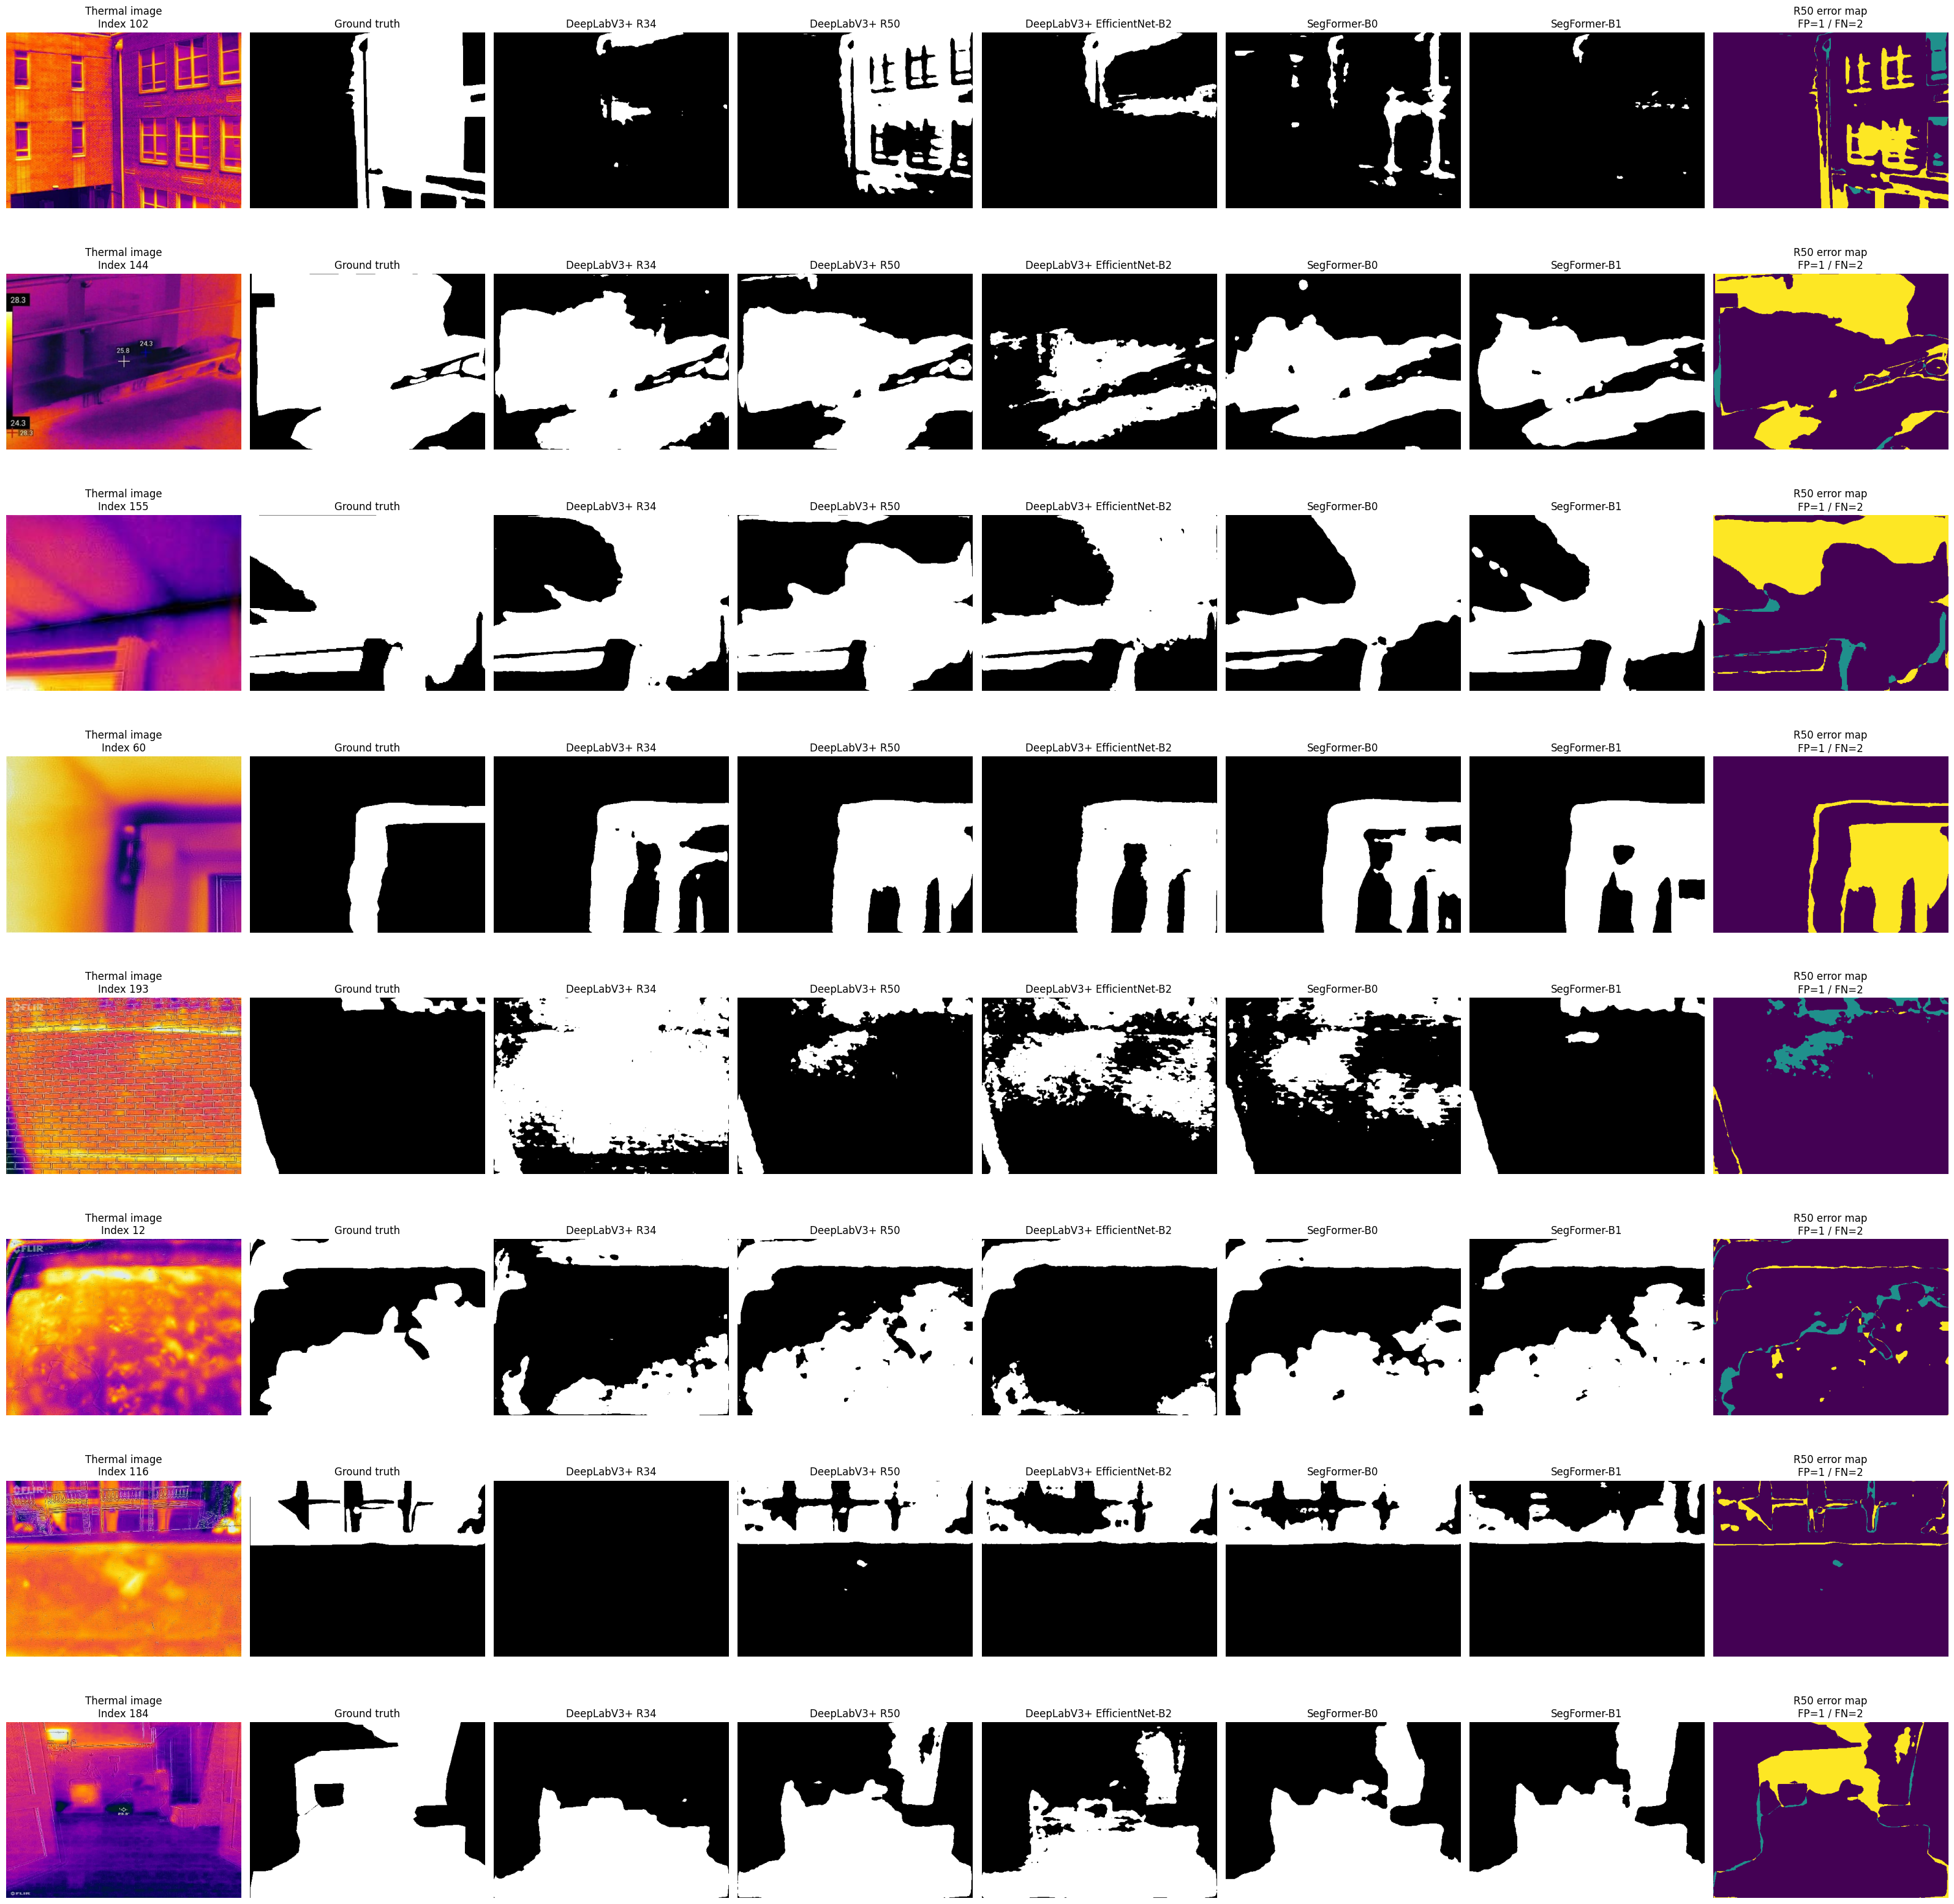

In [22]:
hard_indices = [
    102,
    144,
    155,
    60,
    193,
    12,
    116,
    184
]

compare_hard_cases(
    models,
    test_dataset,
    DEVICE,
    hard_indices
)

In [23]:
# which model won on each difficult image 

@torch.no_grad()
def per_image_metrics(
    models,
    dataset,
    device,
    indices
):

    results = []

    for idx in indices:

        image, mask = dataset[idx]

        input_tensor = (
            image.unsqueeze(0)
            .to(device)
        )

        mask_np = mask[0].numpy().astype(bool)

        row = {
            "index": idx
        }

        for name, model in models.items():

            if "SegFormer" in name:

                outputs = model(
                    pixel_values=input_tensor
                )

                logits = F.interpolate(
                    outputs.logits,
                    size=mask_np.shape,
                    mode="bilinear",
                    align_corners=False
                )

                pred = (
                    torch.softmax(
                        logits,
                        dim=1
                    )[0, 1]
                    .cpu()
                    .numpy()
                    >= 0.5
                )

            else:

                logits = model(input_tensor)

                pred = (
                    torch.sigmoid(logits)[0, 0]
                    .cpu()
                    .numpy()
                    >= 0.5
                )

            intersection = np.logical_and(
                pred,
                mask_np
            ).sum()

            pred_area = pred.sum()
            mask_area = mask_np.sum()

            dice = (
                2 * intersection
                / (pred_area + mask_area + 1e-8)
            )

            fp = np.logical_and(
                pred,
                ~mask_np
            ).sum()

            fn = np.logical_and(
                ~pred,
                mask_np
            ).sum()

            short_name = (
                name
                .replace("DeepLabV3+ ", "")
                .replace("SegFormer-", "")
            )

            row[f"{short_name} Dice"] = dice
            row[f"{short_name} FP"] = fp
            row[f"{short_name} FN"] = fn

        results.append(row)

    return pd.DataFrame(results)

hard_case_results = per_image_metrics(
    models,
    test_dataset,
    DEVICE,
    hard_indices
)

display(hard_case_results)

,index,ResNet34 Dice,ResNet34 FP,ResNet34 FN,ResNet50 Dice,ResNet50 FP,ResNet50 FN,EfficientNet-B2 Dice,EfficientNet-B2 FP,EfficientNet-B2 FN,B0 Dice,B0 FP,B0 FN,B1 Dice,B1 FP,B1 FN
0,102,0.156014,65,78408,0.800313,5481,24860,0.365551,709,66344,0.308333,1706,69737,0.034376,53,84162
1,144,0.848404,3187,39466,0.787393,2003,54391,0.489897,0,107296,0.692932,1153,74011,0.692311,11,74732
2,155,0.843629,2066,41948,0.772487,6927,55202,0.769689,658,59745,0.753340,586,63228,0.850017,2608,39984
3,60,0.678233,25576,37,0.547502,44681,0,0.561036,42276,9,0.612399,34217,0,0.557990,42825,0
4,193,0.150971,141769,142,0.629460,13075,894,0.252128,68656,1015,0.347275,47958,1,0.846402,3704,680
5,12,0.676796,1286,61337,0.955927,7416,3924,0.538389,566,79950,0.915965,1758,18190,0.935835,4598,11260
6,116,0.000000,0,59019,0.933956,1810,5727,0.850181,1147,14532,0.923393,2262,6459,0.697821,473,27138
7,184,0.766460,733,47357,0.869843,2116,27456,0.800834,476,41626,0.864902,1595,28842,0.897522,2607,21352
